<a href="https://colab.research.google.com/github/subinyy/IS_NetShield/blob/main/IS_NetShield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 지능형 유해 URL 탐지 시스템
---

## [패키지 설치]

In [2]:
!pip install -q xgboost lightgbm fastapi uvicorn pyngrok nest-asyncio

import xgboost, lightgbm, sklearn

print(f"XGBoost  {xgboost.__version__}")
print(f"LightGBM {lightgbm.__version__}")
print(f"sklearn  {sklearn.__version__}")

XGBoost  3.2.0
LightGBM 4.6.0
sklearn  1.6.1


## [데이터 업로드]

In [3]:
from google.colab import files
import pandas as pd, os

uploaded = files.upload()

os.makedirs("data", exist_ok=True)
for fname, content in uploaded.items():
    std_name = fname.replace("_v2b", "")
    with open(f"data/{std_name}", "wb") as f:
        f.write(content)
    print(f"{fname} → data/{std_name} ({len(content):,} bytes)")

train = pd.read_csv("data/train.csv")
valid = pd.read_csv("data/valid.csv")
test  = pd.read_csv("data/test.csv")
print(f"\ntrain={len(train):,}  valid={len(valid):,}  test={len(test):,}")

# 클래스 분포 확인
for name, df in [("Train", train), ("Valid", valid), ("Test", test)]:
    vc = df["label"].value_counts()
    print(f"  {name}: 정상(0)={vc[0]:,}  악성(1)={vc[1]:,}  비율={vc[0]/vc[1]:.2f}:1")

Saving test_v2b.csv to test_v2b.csv
Saving train_v2b.csv to train_v2b.csv
Saving valid_v2b.csv to valid_v2b.csv
test_v2b.csv → data/test.csv (530,724 bytes)
train_v2b.csv → data/train.csv (2,901,303 bytes)
valid_v2b.csv → data/valid.csv (751,110 bytes)

train=13,978  valid=3,398  test=2,616
  Train: 정상(0)=6,989  악성(1)=6,989  비율=1.00:1
  Valid: 정상(0)=1,699  악성(1)=1,699  비율=1.00:1
  Test: 정상(0)=1,308  악성(1)=1,308  비율=1.00:1


## [피처 확인 & 데이터 탐색]

/tmp/ipykernel_2219/291454664.py:26: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:26: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


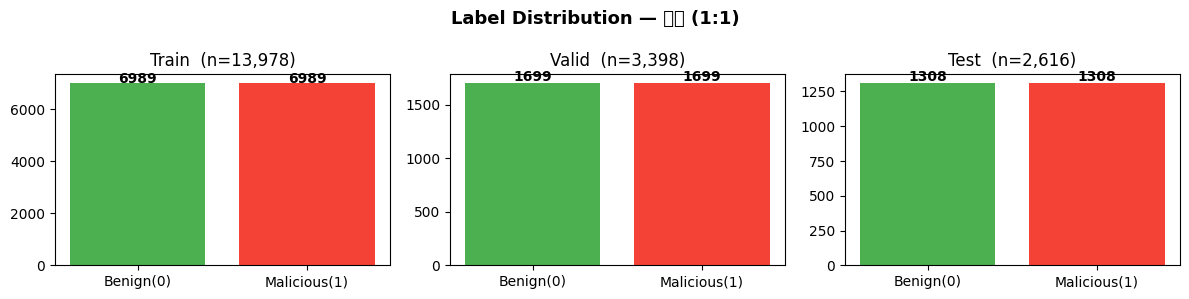

/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219/291454664.py:42: UserWarning: Glyph 47532 (\N{HANGUL

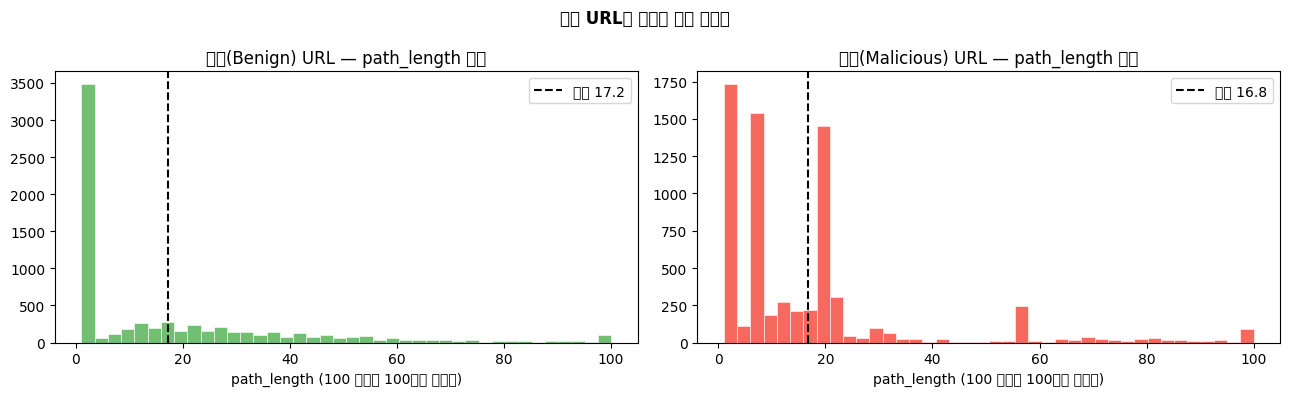


피처별 악성/정상 평균 비교 (ratio = 악성/정상):
                            Benign  Malicious        ratio
has_ip_host               0.000000   0.556589  556588925.5
subdomain_count           0.328802   1.728001          5.3
digit_count               2.904707   9.801831          3.4
dot_count                 1.728573   3.381600          2.0
is_suspicious_tld         0.006868   0.013879          2.0
host_length              15.590356  18.322078          1.2
special_char_count        3.344685   4.012591          1.2
url_length               45.077264  46.053799          1.0
path_length              17.607669  17.138360          1.0
entropy                   3.990449   4.078001          1.0
slash_count               3.864215   3.658606          0.9
uses_shortener_hint       0.062813   0.050079          0.8
hyphen_count              0.932322   0.427672          0.5
has_login_keyword         0.037058   0.011447          0.3
suspicious_keyword_hits   0.105022   0.028759          0.3
param_count           

In [4]:
import matplotlib.pyplot as plt
import numpy as np

FEATURES = [
    "url_length", "host_length", "path_length", "query_length",
    "digit_count", "special_char_count", "dot_count", "hyphen_count",
    "slash_count", "subdomain_count", "param_count",
    "has_ip_host", "has_https_token", "has_login_keyword",
    "suspicious_keyword_hits", "entropy", "is_suspicious_tld",
    "uses_shortener_hint",
]

# 레이블 분포
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, (name, df) in zip(axes, [("Train", train), ("Valid", valid), ("Test", test)]):
    vc = df["label"].value_counts().sort_index()
    bars = ax.bar(["Benign(0)", "Malicious(1)"], vc.values, color=["#4CAF50","#F44336"])
    ax.set_title(f"{name}  (n={len(df):,})")

    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+20, str(v), ha="center", fontweight="bold")

plt.suptitle("Label Distribution — 균형 (1:1)", fontsize=13, fontweight="bold")

plt.tight_layout(); plt.show()

# path_length 분포
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, label, color in [(axes[0], 0, "#4CAF50"), (axes[1], 1, "#F44336")]:
    name = "정상(Benign)" if label == 0 else "악성(Malicious)"
    data = train[train["label"]==label]["path_length"].clip(upper=100)
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name} URL — path_length 분포")
    ax.set_xlabel("path_length (100 이상은 100으로 클리핑)")
    ax.axvline(data.mean(), color="black", linestyle="--", label=f"평균 {data.mean():.1f}")
    ax.legend()

plt.suptitle("정상 URL에 복잡한 경로 포함됨", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

# 피처별 악성/정상 비교
grouped = train.groupby("label")[FEATURES].mean().T
grouped.columns = ["Benign", "Malicious"]
grouped["ratio"] = (grouped["Malicious"] / (grouped["Benign"]+1e-9)).round(1)
print("\n피처별 악성/정상 평균 비교 (ratio = 악성/정상):")
print(grouped.sort_values("ratio", ascending=False).to_string())

## [모델 학습]

In [5]:
import time, pickle, os
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

X_tr, y_tr = train[FEATURES].astype(float), train["label"]
X_va, y_va = valid[FEATURES].astype(float), valid["label"]
X_te, y_te = test[FEATURES].astype(float),  test["label"]
os.makedirs("models", exist_ok=True)

# ── XGBoost ──────────────────────────────────
print("XGBoost 학습 중...")
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", early_stopping_rounds=30,
    random_state=42, n_jobs=-1, verbosity=0,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
print(f"완료 ({time.time()-t0:.1f}s)  best_iter={xgb_model.best_iteration}")

# ── LightGBM ─────────────────────────────────
print("LightGBM 학습 중...")
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(
    X_tr, y_tr, eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
)
print(f"완료 ({time.time()-t0:.1f}s)  best_iter={lgb_model.best_iteration_}")
print("\n두 모델 학습 완료")

XGBoost 학습 중...
완료 (2.0s)  best_iter=51
LightGBM 학습 중...
완료 (0.9s)  best_iter=102

두 모델 학습 완료


## [모델 평가 & 비교]

━━━━ Validation ━━━━

[XGBoost]  AUC=0.9186  AP=0.9350  Acc=0.8505
              precision    recall  f1-score   support

      Benign       0.78      0.98      0.87      1699
   Malicious       0.97      0.72      0.83      1699

    accuracy                           0.85      3398
   macro avg       0.87      0.85      0.85      3398
weighted avg       0.87      0.85      0.85      3398


[LightGBM]  AUC=0.9465  AP=0.9534  Acc=0.8534
              precision    recall  f1-score   support

      Benign       0.78      0.98      0.87      1699
   Malicious       0.97      0.73      0.83      1699

    accuracy                           0.85      3398
   macro avg       0.88      0.85      0.85      3398
weighted avg       0.88      0.85      0.85      3398


━━━━ Test ━━━━

[XGBoost]  AUC=0.9813  AP=0.9865  Acc=0.9446
              precision    recall  f1-score   support

      Benign       0.92      0.98      0.95      1308
   Malicious       0.98      0.91      0.94      1308

    ac

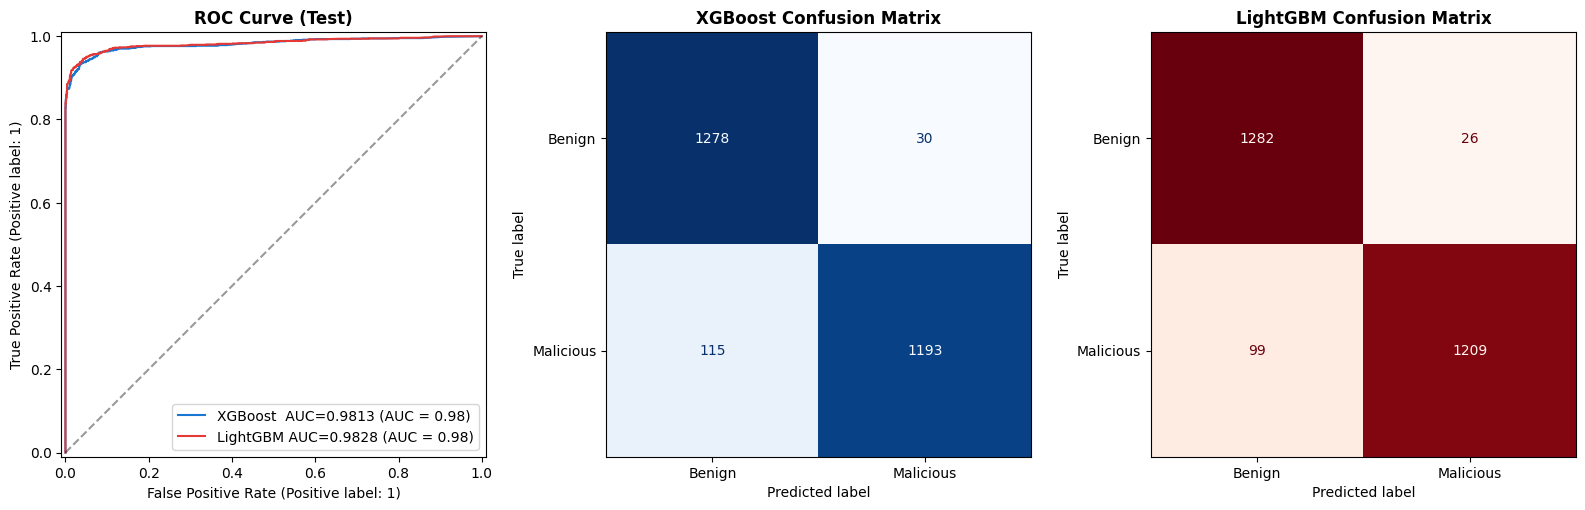

In [6]:
def evaluate(model, name, X, y):
    pred   = model.predict(X)
    proba  = model.predict_proba(X)[:, 1]
    auc    = roc_auc_score(y, proba)
    ap     = average_precision_score(y, proba)
    rep    = classification_report(y, pred, target_names=["Benign","Malicious"], output_dict=True)
    print(f"\n{'='*55}")
    print(f"[{name}]  AUC={auc:.4f}  AP={ap:.4f}  Acc={rep['accuracy']:.4f}")
    print(classification_report(y, pred, target_names=["Benign","Malicious"]))
    return proba, auc

print("━━━━ Validation ━━━━")
xgb_vp, _ = evaluate(xgb_model, "XGBoost",  X_va, y_va)
lgb_vp, _ = evaluate(lgb_model, "LightGBM", X_va, y_va)

print("\n━━━━ Test ━━━━")
xgb_tp, xgb_tauc = evaluate(xgb_model, "XGBoost",  X_te, y_te)
lgb_tp, lgb_tauc = evaluate(lgb_model, "LightGBM", X_te, y_te)

# ROC + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
RocCurveDisplay.from_predictions(y_te, xgb_tp, name=f"XGBoost  AUC={xgb_tauc:.4f}", ax=axes[0], color="#1976D2")
RocCurveDisplay.from_predictions(y_te, lgb_tp, name=f"LightGBM AUC={lgb_tauc:.4f}", ax=axes[0], color="#E53935")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].set_title("ROC Curve (Test)", fontweight="bold")

for ax, (model, name, cmap) in zip(axes[1:], [
    (xgb_model, "XGBoost",  "Blues"),
    (lgb_model, "LightGBM", "Reds"),
]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_te,
        display_labels=["Benign","Malicious"],
        cmap=cmap, ax=ax, colorbar=False,
    )
    ax.set_title(f"{name} Confusion Matrix", fontweight="bold")

plt.tight_layout(); plt.show()

## [피처 중요도 시각화]

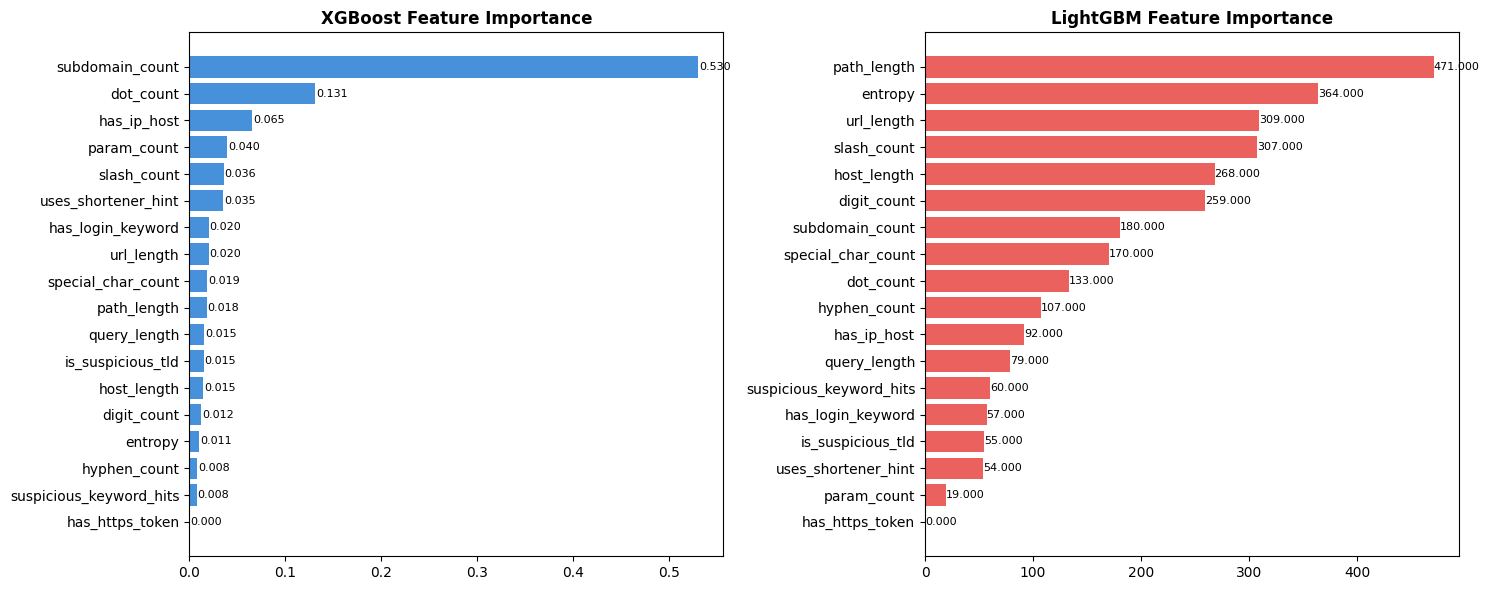

💡: path_length 독주 → subdomain_count·url_length 등 고루 분산
   → 모델이 더 다양한 피처를 활용 = 실운영 환경에서 더 강건함


In [8]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (model, name, color) in zip(axes, [
    (xgb_model, "XGBoost",  "#1976D2"),
    (lgb_model, "LightGBM", "#E53935"),
]):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    bars = ax.barh(fi.index, fi.values, color=color, alpha=0.8)
    ax.set_title(f"{name} Feature Importance", fontweight="bold")
    for bar, val in zip(bars, fi.values):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print("💡: path_length 독주 → subdomain_count·url_length 등 고루 분산")
print("   → 모델이 더 다양한 피처를 활용 = 실운영 환경에서 더 강건함")

## [모델 저장 & 다운로드]

In [9]:
import json
from google.colab import files

best_name  = "XGBoost" if xgb_tauc >= lgb_tauc else "LightGBM"
best_model = xgb_model if xgb_tauc >= lgb_tauc else lgb_model
print(f"최종 선택: {best_name}  (Test AUC={max(xgb_tauc,lgb_tauc):.4f})")

with open("models/url_detector_best.pkl","wb") as f: pickle.dump(best_model, f)
with open("models/features.json","w") as f: json.dump(FEATURES, f, ensure_ascii=False, indent=2)
with open("models/metrics.json","w") as f:
    json.dump({
        "best_model": best_name,
        "dataset_version": "v2b",
        "xgb_test_auc": round(xgb_tauc,4),
        "lgb_test_auc": round(lgb_tauc,4),
        "features": FEATURES,
    }, f, ensure_ascii=False, indent=2)

print("\n다운로드 중...")
files.download("models/url_detector_best.pkl")
files.download("models/features.json")
files.download("models/metrics.json")
print("완료")

최종 선택: LightGBM  (Test AUC=0.9828)

다운로드 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

완료


## [API 서버 준비]

In [10]:
url_features_code = '''
import ipaddress, re, urllib.parse as up
import numpy as np, pandas as pd

SUSPICIOUS_KEYWORDS = [
    "login","signin","verify","update","secure","account","bank","bonus","gift",
    "wallet","confirm","password","auth","invoice","payment","recover","reset",
    "apple","paypal","amazon","microsoft","office","netflix","facebook","meta",
    "telegram","steam","roblox","crypto","airdrop",
]
SUSPICIOUS_TLDS = {"top","xyz","click","work","shop","gq","fit","rest",
                   "country","stream","mom","zip","mov","cam","info","live"}
URL_SHORTENERS = ["bit.ly","tinyurl","cutt.ly","t.co","rb.gy"]
FEATURES = [
    "url_length","host_length","path_length","query_length","digit_count",
    "special_char_count","dot_count","hyphen_count","slash_count","subdomain_count",
    "param_count","has_ip_host","has_https_token","has_login_keyword",
    "suspicious_keyword_hits","entropy","is_suspicious_tld","uses_shortener_hint",
]

def normalize_url(url: str):
    if not isinstance(url, str): return None
    url = url.strip()
    if not url: return None
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+\\-.]*://", url):
        url = "https://" + url
    try:
        p = up.urlsplit(url)
        scheme = p.scheme.lower()
        if scheme not in {"http","https"}: return None
        hostname = p.hostname.lower() if p.hostname else None
        if not hostname: return None
        try: port = p.port
        except: return None
        if (scheme=="http" and port==80) or (scheme=="https" and port==443): port = None
        netloc = hostname + (f":{port}" if port else "")
        path  = re.sub(r"/+", "/", p.path or "/")
        query = up.urlencode(sorted(up.parse_qsl(p.query, keep_blank_values=True)))
        return up.urlunsplit((scheme, netloc, path, query, ""))
    except: return None

def _entropy(s):
    if not s: return 0.0
    counts = np.array(list(pd.Series(list(s)).value_counts().values), dtype=float)
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

def _is_ip(host):
    try: ipaddress.ip_address(host); return 1
    except: return 0

def extract_features(url: str) -> dict:
    norm = normalize_url(url)
    if norm is None: return {f: 0 for f in FEATURES}
    try: p = up.urlsplit(norm)
    except: return {f: 0 for f in FEATURES}
    host = p.hostname or ""; path = p.path or ""; query = p.query or ""
    fl = norm.lower(); hl = host.lower(); pq = (path+"?"+query).lower()
    return {
        "url_length": len(norm), "host_length": len(host),
        "path_length": len(path), "query_length": len(query),
        "digit_count": sum(c.isdigit() for c in norm),
        "special_char_count": sum(c in ".@-_=+%?&#!$," for c in norm),
        "dot_count": norm.count("."), "hyphen_count": norm.count("-"),
        "slash_count": norm.count("/"),
        "subdomain_count": max(len(host.split("."))-2,0) if host else 0,
        "param_count": len(up.parse_qsl(query,keep_blank_values=True)) if query else 0,
        "has_ip_host": _is_ip(host),
        "has_https_token": int("https" in hl or "https" in pq),
        "has_login_keyword": int(any(k in fl for k in ["login","signin","verify","password","account"])),
        "suspicious_keyword_hits": sum(k in fl for k in SUSPICIOUS_KEYWORDS),
        "entropy": round(_entropy(norm),4),
        "is_suspicious_tld": int(hl.rsplit(".",1)[-1] in SUSPICIOUS_TLDS if "." in hl else 0),
        "uses_shortener_hint": int(any(x in hl for x in URL_SHORTENERS)),
    }

def extract_features_batch(urls):
    return pd.DataFrame([extract_features(u) for u in urls])[FEATURES]
'''

with open("url_features.py","w") as f:
    f.write(url_features_code)
print("url_features.py 생성 완료")

from url_features import extract_features, normalize_url
t = "http://login-paypal-verify.top/secure/confirm?s=abc"
feat = extract_features(t)
print(f"테스트: entropy={feat['entropy']}  kw_hits={feat['suspicious_keyword_hits']}  susp_tld={feat['is_suspicious_tld']}")

✅ url_features.py 생성 완료
테스트: entropy=4.4708  kw_hits=5  susp_tld=1


## FastAPI 서버 실행 (ngrok 터널)
> **ngrok 토큰**: https://dashboard.ngrok.com/get-started/your-authtoken

In [ ]:
NGROK_TOKEN = "여기에_ngrok_토큰_붙여넣기"   # ← 수정 필요

from pyngrok import ngrok, conf
conf.get_default().auth_token = NGROK_TOKEN

import nest_asyncio, uvicorn, threading, pickle, json, time
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
import pandas as pd
from url_features import extract_features, normalize_url, FEATURES

nest_asyncio.apply()

with open("models/url_detector_best.pkl","rb") as f: _model = pickle.load(f)
_meta = json.load(open("models/metrics.json"))
print(f"✅ 모델 로드: {_meta['best_model']}  (dataset={_meta['dataset_version']})")

THRESHOLD = 0.5
app = FastAPI(title="유해 URL 탐지 API v2b", version="2.0.0")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

class URLRequest(BaseModel):
    url: str
    threshold: Optional[float] = None

class BatchURLRequest(BaseModel):
    urls: list[str]
    threshold: Optional[float] = None

def _predict(url, thr):
    feat = extract_features(url)
    df   = pd.DataFrame([feat])[FEATURES].astype(float)
    prob = float(_model.predict_proba(df)[0,1])
    is_mal = prob >= thr
    if   prob >= 0.85: conf_lv, risk = "HIGH",   "DANGEROUS"
    elif prob >= thr:  conf_lv, risk = "MEDIUM",  "SUSPICIOUS"
    elif prob >= 0.3:  conf_lv, risk = "LOW",     "SUSPICIOUS"
    else:              conf_lv, risk = "HIGH",    "SAFE"
    return {"url":url,"normalized_url":normalize_url(url),"is_malicious":is_mal,
            "probability":round(prob,4),"confidence":conf_lv,"risk_level":risk,
            "features":feat,"threshold_used":thr}

@app.get("/health")
def health(): return {"status":"ok","model":_meta["best_model"],"dataset":_meta["dataset_version"]}

@app.get("/model/info")
def info(): return {"model":_meta["best_model"],"dataset_version":_meta["dataset_version"],
                    "features":FEATURES,"threshold":THRESHOLD,
                    "test_auc":_meta.get(f"{_meta['best_model'].lower()[:3]}_test_auc")}

@app.post("/predict")
def predict(req: URLRequest):
    return _predict(req.url.strip(), req.threshold or THRESHOLD)

@app.post("/predict/batch")
def predict_batch(req: BatchURLRequest):
    thr = req.threshold or THRESHOLD
    t0  = time.time()
    results = [_predict(u.strip(), thr) for u in req.urls]
    n_mal = sum(1 for r in results if r["is_malicious"])
    return {"results":results,
            "summary":{"total":len(results),"malicious":n_mal,"safe":len(results)-n_mal,
                       "malicious_ratio":round(n_mal/len(results),4)},
            "elapsed_ms":round((time.time()-t0)*1000,1)}

public_url = ngrok.connect(8000).public_url
print(f"\n🌐 공개 URL : {public_url}")
print(f"📄 Swagger  : {public_url}/docs")

threading.Thread(target=lambda: uvicorn.run(app, host="0.0.0.0", port=8000), daemon=True).start()
time.sleep(2); print("\n✅ 서버 실행 중!")

## API 테스트

In [ ]:
import requests

BASE = "http://localhost:8000"
print("[health]", requests.get(f"{BASE}/health").json())

test_cases = [
    ("정상", "https://google.com"),
    ("정상", "https://www.wikipedia.org/wiki/Machine_learning"),
    ("정상", "https://amazon.com/dp/B09G3HRMVB?ref=sr_1_1"),
    ("의심", "http://bit.ly/3xAbcDE"),
    ("악성", "http://login-paypal-verify.top/secure/confirm?session=abc"),
    ("악성", "http://180.252.221.19:56481/shell.php"),
    ("악성", "http://secure-apple-id-verify.xyz/account/reset/password"),
]

print(f"\n{'예상':<6} {'결과':<16} {'확률':>6}  URL")
print("─"*70)
for expected, url in test_cases:
    r = requests.post(f"{BASE}/predict", json={"url": url}).json()
    icon   = "🔴" if r["is_malicious"] else "🟢"
    result = f"{icon} {r['risk_level']}"
    print(f"{expected:<6} {result:<18} {r['probability']:>5.3f}  {url[:50]}")

# 배치
print("\n━━━━ 배치 ━━━━")
r = requests.post(f"{BASE}/predict/batch", json={"urls":[u for _,u in test_cases]}).json()
s = r["summary"]
print(f"총 {s['total']}건  악성 {s['malicious']}건  정상 {s['safe']}건  {r['elapsed_ms']}ms")

## 임계값(Threshold) 조정 실험

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba_te = best_model.predict_proba(X_te.astype(float))[:,1]
thresholds = np.arange(0.1, 0.95, 0.05)
metrics = {"precision":[], "recall":[], "f1":[], "fpr":[]}

for thr in thresholds:
    yp = (y_proba_te >= thr).astype(int)
    metrics["precision"].append(precision_score(y_te, yp, zero_division=0))
    metrics["recall"].append(recall_score(y_te, yp, zero_division=0))
    metrics["f1"].append(f1_score(y_te, yp, zero_division=0))
    tn = ((yp==0)&(y_te==0)).sum(); fp = ((yp==1)&(y_te==0)).sum()
    metrics["fpr"].append(fp/(fp+tn+1e-9))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(thresholds, metrics["precision"], "b-o", ms=4, label="Precision")
ax1.plot(thresholds, metrics["recall"],    "r-o", ms=4, label="Recall")
ax1.plot(thresholds, metrics["f1"],        "g-o", ms=4, label="F1")
ax1.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="기본값 0.5")
ax1.set_title("Threshold vs Precision / Recall / F1", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(thresholds, metrics["fpr"], "m-o", ms=4)
ax2.axvline(0.5, color="gray", linestyle="--", alpha=0.7)
ax2.set_title("Threshold vs FPR (오탐율)", fontweight="bold")
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_idx = np.argmax(metrics["f1"])
print(f"F1 최고 임계값: {thresholds[best_idx]:.2f}")
print(f"  Precision={metrics['precision'][best_idx]:.4f}  Recall={metrics['recall'][best_idx]:.4f}  F1={metrics['f1'][best_idx]:.4f}")